In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import tqdm
import matplotlib.pyplot as plt
from imblearn.ensemble import BalancedBaggingClassifier, BalancedRandomForestClassifier
from pygam import LogisticGAM, s, f, te
import xarray as xr
import glob
import netCDF4 as nc

In [27]:
def load_data():
    #Code from optimise_pss() in event_analysis.py
    
    #Load ERA5 environmental data at point locations
    model = pd.read_pickle("/g/data/eg3/ab4502/ExtremeWind/points/era5_allvars_v3_2005_2018.pkl").dropna()
    param_list = np.delete(np.array(model.columns), \
                    np.where((np.array(model.columns)=="lat") | \
                    (np.array(model.columns)=="lon") | \
                    (np.array(model.columns)=="loc_id") | \
                    (np.array(model.columns)=="time")))
    
    #Load observational data
    obs = pd.read_pickle("/g/data/eg3/ab4502/ExtremeWind/obs/aws/convective_wind_gust_aus_2005_2018.pkl")
    obs["hourly_ceil_utc"] = pd.DatetimeIndex(obs["gust_time_utc"]).ceil("1H")
    
    #Merge the observational data with the environmental data
    df_aws = pd.merge(obs[["stn_name","wind_gust","hourly_floor_utc","tc_affected","lightning","is_sta"]],\
        model, how="left",left_on=["stn_name","hourly_floor_utc"], right_on=["loc_id","time"]).dropna(subset=param_list).\
        dropna(subset=["wind_gust"])
    df_aws = df_aws[df_aws.tc_affected==0]
    
    #Create target variable
    df_aws.loc[:,"is_conv_aws"] = 0
    df_aws.loc[(df_aws.lightning >= 2) & (df_aws.wind_gust >= 25), "is_conv_aws"] = 1
    
    return df_aws

def train_binary_mod(df, classifier, preds, target):
    
    mod = classifier.fit(df[preds], df[target].values.ravel())
    
    return mod

def train_test_binary_mod(df, classifier, preds, target, n_split, test_size):
    
    auc_scores = []
    for train, test in tqdm.tqdm(StratifiedShuffleSplit(n_split,test_size=test_size).split(X=df[preds],y=df[target].values.ravel())):
        mod_split = train_binary_mod(df.iloc[train], classifier, preds, target)
        auc_scores.append(roc_auc_score(df.iloc[test][target],mod_split.predict_proba(df.iloc[test][preds])[:,1]))
        
    return auc_scores

def train_test_multi_mod(df, classifier, preds, target, n_split, test_size):
    
    auc_scores = []
    for train, test in tqdm.tqdm(StratifiedShuffleSplit(n_split,test_size=test_size).split(X=df[preds],y=df[target].values.ravel())):
        mod_split = train_binary_mod(df.iloc[train], classifier, preds, target)
        auc_scores.append(roc_auc_score(df.iloc[test][target],mod_split.predict_proba(df.iloc[test][preds]),multi_class="ovr",
                                       average="weighted"))
        
    return auc_scores

In [3]:
#Load data

env_var = ["ebwd","Umean800_600","lr13","rhmin13","srhe_left","q_melting","eff_lcl",\
          "qmean01","Umean06","s06","is_conv_aws"]
target="is_conv_aws"
df = load_data()

np.random.seed(0)

## Lets first define some AUC scores to beat. Using the model wind gust, CAPE, Total totals, and the DCP 

In [14]:
print("AUC using the model wind gust: ",roc_auc_score(df["is_conv_aws"],df["wg10"]))
print("AUC using CAPE: ",roc_auc_score(df["is_conv_aws"],df["mu_cape"]))
print("AUC using DCP: ",roc_auc_score(df["is_conv_aws"],df["dcp"]))
print("AUC using total totals: ",roc_auc_score(df["is_conv_aws"],df["t_totals"]))

AUC using the model wind gust:  0.6685893042873983
AUC using CAPE:  0.7920414653976195
AUC using DCP:  0.8507420733671298
AUC using total totals:  0.9032488213260458


## Train the logistic regression model as previously done in JSHESS paper. Firstly train/test on the entire data, then do a cross-validation

In [65]:
logit_preds = ["ebwd","Umean800_600","lr13","rhmin13","srhe_left","q_melting","eff_lcl"]

logit_mod = train_binary_mod(df,
                             LogisticRegression(class_weight="balanced",solver="liblinear",max_iter=1000),
                             logit_preds,
                             ["is_conv_aws"])
                            
roc_auc_score(df[target],logit_mod.predict_proba(df[logit_preds])[:,1])

0.9540403568775986

20it [00:25,  1.29s/it]


0.9526074270753213


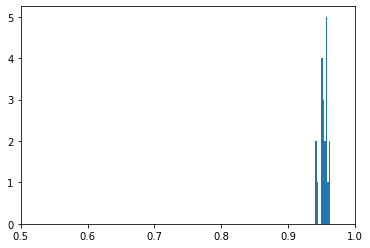

In [68]:
#Test this model as in the JSHESS paper - by using a train/test split
    
auc_scores = train_test_binary_mod(df,
                                   LogisticRegression(class_weight="balanced",solver="liblinear",max_iter=1000),
                                   logit_preds,
                                   ["is_conv_aws"],
                                   20,
                                   0.2)
                                   
hist=plt.hist(auc_scores); plt.xlim([0.5,1])    
print(np.mean(auc_scores))

## Do the same thing, but use bagging to train on balanced data, rather than using the "balanced" option in LogisticRegression

In [69]:
#Try the same thing but with balanced bagging. Firstly, train/test on the entire data
bagging_preds = ["ebwd","Umean800_600","lr13","rhmin13","srhe_left","q_melting","eff_lcl"]
bagging = BalancedBaggingClassifier(base_estimator=LogisticRegression(max_iter=1000),
                                        n_estimators=50,
                                        sampling_strategy='majority')
bagging_mod = train_binary_mod(df,
                             bagging,
                             bagging_preds,
                             ["is_conv_aws"])
roc_auc_score(df[target],bagging_mod.predict_proba(df[bagging_preds])[:,1])

0.9544966650079679

20it [01:16,  3.83s/it]


0.9546075306194901


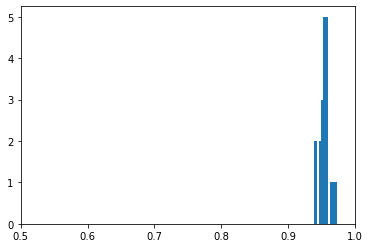

In [70]:
auc_scores = train_test_binary_mod(df,
                                   bagging_mod,
                                   bagging_preds,
                                   ["is_conv_aws"],
                                   20,
                                   0.2)
                                   
hist=plt.hist(auc_scores); plt.xlim([0.5,1])    
print(np.mean(auc_scores))

## While we are doing bagging, lets try a random forest

In [82]:
#Firstly, use the same predictors as selected for the Logistic Regression model
balanced_rf_preds = ["ebwd","Umean800_600","lr13","rhmin13","srhe_left","q_melting","eff_lcl"]
balanced_rf = BalancedRandomForestClassifier(n_estimators=100,
                                             max_depth=None,
                                             sampling_strategy='majority',
                                             max_features=None
                                            )
balanced_rf_mod = train_binary_mod(df,
                             balanced_rf,
                             balanced_rf_preds,
                             ["is_conv_aws"])
roc_auc_score(df[target],balanced_rf_mod.predict_proba(df[balanced_rf_preds])[:,1])


0.9834143799218329

20it [00:59,  2.97s/it]


0.9479425773622865


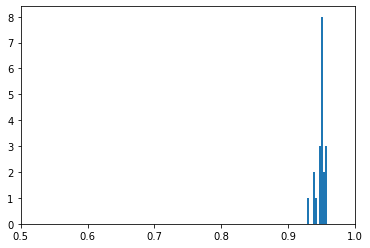

In [83]:
auc_scores = train_test_binary_mod(df,
                                   balanced_rf_mod,
                                   balanced_rf_preds,
                                   ["is_conv_aws"],
                                   20,
                                   0.2)
                                   
hist=plt.hist(auc_scores); plt.xlim([0.5,1])    
print(np.mean(auc_scores))

In [49]:
#Try with all predictors and let the decision tree decide. As in our JSHESS paper, this is all "variables" (not including indices)
rf_preds = np.array(['ml_cape', 'mu_cape', 'sb_cape',\
             'ml_cin', 'sb_cin', 'mu_cin', 'ml_lcl', 'mu_lcl', 'sb_lcl', 'eff_cape',\
             'eff_cin', 'eff_lcl', 'lr01', 'lr03', 'lr13', 'lr36', 'lr24', 'lr_freezing',\
             'lr_subcloud', 'qmean01', 'qmean03', 'qmean06', 'qmeansubcloud', 'q_melting',\
             'q1', 'q3', 'q6', 'rhmin01', 'rhmin03', 'rhmin13', 'rhminsubcloud', 'tei', 'wbz',\
             'mhgt', 'mu_el', 'ml_el', 'sb_el', 'eff_el', 'pwat', \
             'te_diff', 'dpd850', 'dpd700', 'dcape', 'ddraft_temp', 'sfc_thetae',\
             'srhe_left', 'srh01_left', 'srh03_left', 'srh06_left', 'ebwd', 's010', 's06',\
             's03', 's01', 's13', 's36', 'scld', 'U500', 'U10', 'U1', 'U3', 'U6', 'Ust_left',\
             'Usr01_left', 'Usr03_left', 'Usr06_left', 'Uwindinf', 'Umeanwindinf',\
             'Umean800_600', 'Umean06', 'Umean01', 'Umean03'])
rf = BalancedRandomForestClassifier(n_estimators=100,
                                             max_depth=None,
                                             sampling_strategy='majority',
                                             max_features="sqrt"
                                            )
rf_mod = train_binary_mod(df,
                          rf,
                          rf_preds,
                          ["is_conv_aws"])
roc_auc_score(df[target],rf_mod.predict_proba(df[rf_preds])[:,1])


0.9933442664113045

In [50]:
#Lets look at the top-10 variables (highest gini score = variables that sort the best)
pd.DataFrame({"fi":rf.feature_importances_},index=rf_preds).sort_values("fi",ascending=False).iloc[0:10]

,fi
q_melting,0.066743
dpd700,0.059319
Uwindinf,0.046297
lr13,0.036175
lr24,0.036012
mu_cape,0.030580
ml_el,0.030086
eff_lcl,0.029533
Umean03,0.027615
mu_el,0.025284


50it [02:32,  3.06s/it]

0.9644404916868823


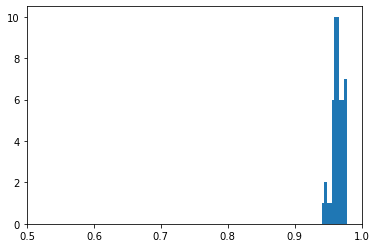

In [51]:
auc_scores = train_test_binary_mod(df,
                                   rf_mod,
                                   rf_preds,
                                   ["is_conv_aws"],
                                   50,
                                   0.2)
                                   
hist=plt.hist(auc_scores); plt.xlim([0.5,1])    
print(np.mean(auc_scores))

In [54]:
import joblib
joblib.dump(rf_mod, "/g/data/eg3/ab4502/ExtremeWind/rf_clf.joblib")


['/g/data/eg3/ab4502/ExtremeWind/rf_clf.joblib']

In [101]:
#Try with the top 10 variables as selected by the random forest
rf10_preds = np.array(pd.DataFrame({"fi":rf.feature_importances_},index=rf_preds).sort_values("fi",ascending=False).iloc[0:10].index)
rf10 = BalancedRandomForestClassifier(n_estimators=100,
                                             max_depth=None,
                                             sampling_strategy='majority',
                                             max_features=None
                                            )
rf10_mod = train_binary_mod(df,
                          rf10,
                          rf10_preds,
                          ["is_conv_aws"])
roc_auc_score(df[target],rf10_mod.predict_proba(df[rf10_preds])[:,1])


0.9874219709582048

20it [01:03,  3.19s/it]

0.9527644629016034


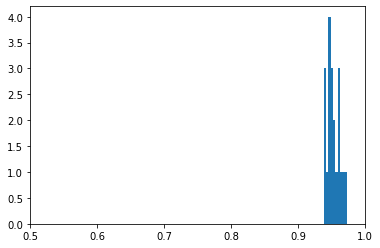

In [102]:
auc_scores = train_test_binary_mod(df,
                                   rf10_mod,
                                   rf10_preds,
                                   ["is_conv_aws"],
                                   20,
                                   0.2)
                                   
hist=plt.hist(auc_scores); plt.xlim([0.5,1])    
print(np.mean(auc_scores))

## Try a GAM

In [4]:
gam_preds = ["ebwd","Umean800_600","lr13","rhmin13","srhe_left","q_melting","eff_lcl"]

resample_null = resample(df[df["is_conv_aws"]==0],replace=True,n_samples=df["is_conv_aws"].sum()*10,random_state=0)
resampled = pd.concat([resample_null, df[df["is_conv_aws"]==1]], axis=0)

#gam = LogisticGAM(s(0)+s(1)+s(2)+s(3)+s(4)+s(5)+s(6),verbose=False,max_iter=1000).gridsearch(resampled[gam_preds].values,resampled["is_conv_aws"])
gam = LogisticGAM(s(0)+s(1)+s(2)+s(3)+s(4)+s(5)+s(6),verbose=True,max_iter=1000).gridsearch(df[gam_preds].values,df["is_conv_aws"])

roc_auc_score(df["is_conv_aws"],gam.predict_proba(df[gam_preds]))

100% (11 of 11) |########################| Elapsed Time: 0:04:48 Time:  0:04:48


0.9555837727010219

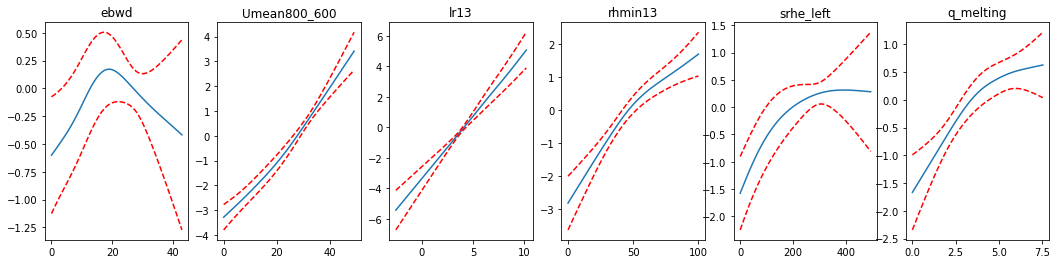

In [5]:
fig, axs = plt.subplots(1, 6,figsize=[18,4])
titles = gam_preds

for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, width=.95)

    ax.plot(XX[:, i], pdep)
    ax.plot(XX[:, i], confi, c='r', ls='--')
    ax.set_title(titles[i]);

## To summarise: The mean AUCs (over 20 train/test splits, except for GAM) are
* Logistic regression: 0.953
* Bagged logistic regression: 0.955
* Random forest (same predicros as logistic regression): 0.948
* Random forest (all variables as predictors): 0.963
* Random forest (top-10 variables from full random forest): 0.953
* GAM: 0.956

Best pre-existing diagnostic
* Total totals: 0.903

## Try multi-class prediction, based on clustering using a set of 36 SCW cases

In [4]:
#First, apply the k-means clustering from the case study analysis
#All this code does is replicate that clustering 

def get_env_clusters():
        #This is just the code from auto_case_driver/kmeans_and_cluster_eval.ipynb - instead of loading in the clustering from disk
        details_list = pd.read_csv("/g/data/eg3/ab4502/figs/ExtremeWind/case_studies/case_study_list.csv")
        details_list["gust_time_utc"] = pd.DatetimeIndex(details_list.gust_time_utc)
        details_list["rid"] = details_list.rid.astype(str)
        details_list["stn_id"] = details_list.stn_id.astype(str).str.pad(width=6,side="left",fillchar="0")
        var=["s06","qmean01","lr13","Umean06"]
        df = pd.DataFrame()
        for index, row in details_list.iterrows():
                df = pd.concat([df,
                        get_point_data(row["gust_time_utc"], row["lat"], row["lon"], 50, var, plot=False).T],
                                axis=0)

        df_norm = (df - df.min(axis=0)) / (df.max(axis=0) - df.min(axis=0))
        mod=KMeans(n_clusters=3, verbose=0, random_state=0)
        mod_fit=mod.fit(df_norm[var])
        cluster_index = mod_fit.predict(df_norm[var])

        return mod_fit, df

def get_point_data(time,lat,lon,r,var,plot=False,vmin=None,vmax=None):

    f = xr.open_dataset(glob.glob("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_"\
                            +time.strftime("%Y%m")+"*.nc")[0])[var].sel({"time":time.replace(minute=0)})

    lats = f.coords.get("lat").values
    lons = f.coords.get("lon").values
    x,y = np.meshgrid(lons,lats)
    dist_km = (latlon_dist(lat, lon, y, x) )
    mask = get_mask(lons,lats)
    a,b = np.where( (dist_km <= r) & (mask == 1) )
    target_lons = xr.DataArray(lons[b],dims="points")
    target_lats = xr.DataArray(lats[a],dims="points")
    f_slice = (f.sel(lon=target_lons, lat=target_lats))

    if plot:
        plt.figure()
        ax=plt.axes(projection=ccrs.PlateCarree())
        temp = np.where((dist_km <= r) & (mask == 1), f.values, np.nan)
        c=ax.pcolormesh(x,y,temp,vmin=vmin,vmax=vmax)
        plt.colorbar(c)
        ax.coastlines()

    #Return the value of the point with the highest absolute value
    return pd.DataFrame([f_slice[v].values[np.abs(f_slice[v]).argmax()] for v in var], index=var)    
    
def latlon_dist(lat, lon, lats, lons):

        #Calculate great circle distance (Harversine) between a lat lon point (lat, lon) and a list of lat lon
        # points (lats, lons)

        R = 6373.0

        lat1 = np.deg2rad(lat)
        lon1 = np.deg2rad(lon)
        lat2 = np.deg2rad(lats)
        lon2 = np.deg2rad(lons)

        dlon = lon2 - lon1
        dlat = lat2 - lat1

        a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

        return (R * c)

def get_mask(lon,lat,thresh=0.5):
    #Return lsm for a given domain (with lats=lat and lons=lon)
    lsm,nat_lon,nat_lat = get_lsm()
    lon_ind = np.where((nat_lon >= lon[0]) & (nat_lon <= lon[-1]))[0]
    lat_ind = np.where((nat_lat >= lat[-1]) & (nat_lat <= lat[0]))[0]
    lsm_domain = lsm[(lat_ind[0]):(lat_ind[-1]+1),(lon_ind[0]):(lon_ind[-1]+1)]
    lsm_domain = np.where(lsm_domain > thresh, 1, 0)

    return lsm_domain

def get_lsm():
    #Load the ERA5 land-sea fraction
    lsm_file = nc.Dataset("/g/data/rt52/era5/single-levels/reanalysis/lsm/1979/lsm_era5_oper_sfc_19790101-19790131.nc")
    lsm = np.squeeze(lsm_file.variables["lsm"][0])
    lsm_lon = np.squeeze(lsm_file.variables["longitude"][:])
    lsm_lat = np.squeeze(lsm_file.variables["latitude"][:])
    lsm_file.close()
    return [lsm,lsm_lon,lsm_lat]    
    
def transform_to_cluster(f, cluster_mod, cluster_input):

    s06 = (f["s06"] - cluster_input["s06"].min()) / (cluster_input["s06"].max()-cluster_input["s06"].min())
    qmean01 = (f["qmean01"] - cluster_input["qmean01"].min()) / (cluster_input["qmean01"].max()-cluster_input["qmean01"].min())
    lr13 = (f["lr13"] - cluster_input["lr13"].min()) / (cluster_input["lr13"].max()-cluster_input["lr13"].min())
    Umean06 = (f["Umean06"] - cluster_input["Umean06"].min()) / (cluster_input["Umean06"].max()-cluster_input["Umean06"].min())

    return s06, qmean01, lr13, Umean06




In [5]:
#Fit the clusters again using kmeans (based on 36 cases)
cluster_mod, cluster_input = get_env_clusters()
#Transform the full dataset, ready for clustering
s06, qmean01, lr13, Umean06 = transform_to_cluster(df, cluster_mod, cluster_input)
#Perform the clustering on the full dataset
cluster_out = cluster_mod.predict(pd.concat([s06, qmean01, lr13, Umean06],axis=1).astype(np.float64))
df["cluster"] = cluster_out


### Multiclass logistic regression

In [6]:
logit_preds = ["ebwd","Umean800_600","lr13","rhmin13","srhe_left","q_melting","eff_lcl"]

logit_mod = train_binary_mod(df[df["cluster"]==0],
                             LogisticRegression(class_weight="balanced",solver="liblinear",max_iter=1000),
                             logit_preds,
                             ["is_conv_aws"])
print("Cluster 0 AUC: ",roc_auc_score(df[df["cluster"]==0][target],logit_mod.predict_proba(df[df["cluster"]==0][logit_preds])[:,1]))

logit_mod = train_binary_mod(df[df["cluster"]==1],
                             LogisticRegression(class_weight="balanced",solver="liblinear",max_iter=1000),
                             logit_preds,
                             ["is_conv_aws"])
print("Cluster 1 AUC: ",roc_auc_score(df[df["cluster"]==1][target],logit_mod.predict_proba(df[df["cluster"]==1][logit_preds])[:,1]))

logit_mod = train_binary_mod(df[df["cluster"]==2],
                             LogisticRegression(class_weight="balanced",solver="liblinear",max_iter=1000),
                             logit_preds,
                             ["is_conv_aws"])
print("Cluster 2 AUC: ",roc_auc_score(df[df["cluster"]==2][target],logit_mod.predict_proba(df[df["cluster"]==2][logit_preds])[:,1]))

Cluster 0 AUC:  0.9440455420403817
Cluster 1 AUC:  0.94782430312133
Cluster 2 AUC:  0.9747608580485846


In [45]:
df["multi"] = (np.where(df["is_conv_aws"]==1,df.cluster+1,0))
logit_mod = train_binary_mod(df,
                             LogisticRegression(class_weight="balanced",solver="liblinear",max_iter=1000),
                             logit_preds,
                             ["multi"])
roc_auc_score(df["multi"],logit_mod.predict_proba(df[logit_preds]),multi_class="ovr",average="weighted")

0.9560497362393824

20it [01:30,  4.54s/it]


0.9508436725340568


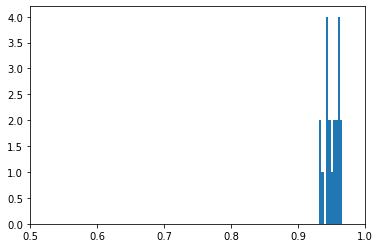

In [28]:
auc_scores = train_test_multi_mod(df,
                                   logit_mod,
                                   logit_preds,
                                   ["multi"],
                                   20,
                                   0.2)
                                   
hist=plt.hist(auc_scores); plt.xlim([0.5,1])    
print(np.mean(auc_scores))

In [39]:
pd.DataFrame(logit_mod.coef_,columns=logit_preds)

,ebwd,Umean800_600,lr13,rhmin13,srhe_left,q_melting,eff_lcl
0,-0.026079,-0.112673,-0.261600,-0.009647,-0.009721,-0.272806,-0.000633
1,0.096024,0.173409,2.625821,0.040057,0.007001,0.966683,0.000222
2,0.077269,-0.052698,1.221459,0.068300,0.028149,0.283242,0.000438
3,0.105377,0.299140,0.391833,0.045198,0.006448,-0.038010,-0.001173


In [44]:
df.multi.value_counts()

0    169006
2       101
3        56
1        45
Name: multi, dtype: int64

In [43]:
roc_auc_score(df["multi"],
              logit_mod.predict_proba(df[logit_preds]),
              multi_class="ovr",
             average="weighted")

0.9561015575275303

### Multiclass random forest

0it [00:00, ?it/s]

Cluster 0 AUC:  0.9884113527460376


20it [00:09,  2.09it/s]

0.9245781627554575


,fi
pwat,0.073638
qmean06,0.072091
mu_el,0.054672
qmean03,0.053074
q3,0.042546
qmean01,0.040799
q6,0.034956
q_melting,0.032296
q1,0.030142
sfc_thetae,0.028969


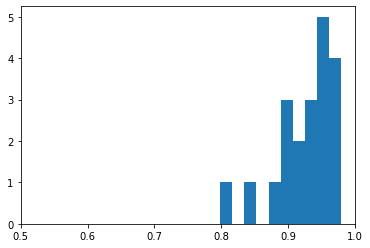

In [9]:
#Try with all predictors and let the decision tree decide. As in our JSHESS paper, this is all "variables" (not including indices)
rf_preds = np.array(['ml_cape', 'mu_cape', 'sb_cape',\
             'ml_cin', 'sb_cin', 'mu_cin', 'ml_lcl', 'mu_lcl', 'sb_lcl', 'eff_cape',\
             'eff_cin', 'eff_lcl', 'lr01', 'lr03', 'lr13', 'lr36', 'lr24', 'lr_freezing',\
             'lr_subcloud', 'qmean01', 'qmean03', 'qmean06', 'qmeansubcloud', 'q_melting',\
             'q1', 'q3', 'q6', 'rhmin01', 'rhmin03', 'rhmin13', 'rhminsubcloud', 'tei', 'wbz',\
             'mhgt', 'mu_el', 'ml_el', 'sb_el', 'eff_el', 'pwat', \
             'te_diff', 'dpd850', 'dpd700', 'dcape', 'ddraft_temp', 'sfc_thetae',\
             'srhe_left', 'srh01_left', 'srh03_left', 'srh06_left', 'ebwd', 's010', 's06',\
             's03', 's01', 's13', 's36', 'scld', 'U500', 'U10', 'U1', 'U3', 'U6', 'Ust_left',\
             'Usr01_left', 'Usr03_left', 'Usr06_left', 'Uwindinf', 'Umeanwindinf',\
             'Umean800_600', 'Umean06', 'Umean01', 'Umean03'])
rf = BalancedRandomForestClassifier(n_estimators=100,
                                             max_depth=None,
                                             sampling_strategy='majority',
                                             max_features="sqrt"
                                            )
rf_mod0 = train_binary_mod(df[df["cluster"]==0],
                          rf,
                          rf_preds,
                          ["is_conv_aws"])
print("Cluster 0 AUC: ",roc_auc_score(df[df["cluster"]==0][target],rf_mod0.predict_proba(df[df["cluster"]==0][rf_preds])[:,1]))

auc_scores = train_test_binary_mod(df[df["cluster"]==0],
                                   rf_mod0,
                                   rf_preds,
                                   ["is_conv_aws"],
                                   20,
                                   0.2)
                                   
hist=plt.hist(auc_scores); plt.xlim([0.5,1])    
print(np.mean(auc_scores))

pd.DataFrame({"fi":rf_mod0.feature_importances_},index=rf_preds).sort_values("fi",ascending=False).iloc[0:10]

In [134]:
rf_mod1 = train_binary_mod(df[df["cluster"]==1],
                          rf,
                          rf_preds,
                          ["is_conv_aws"])
print("Cluster 1 AUC: ",roc_auc_score(df[df["cluster"]==1][target],rf_mod1.predict_proba(df[df["cluster"]==1][rf_preds])[:,1]))
pd.DataFrame({"fi":rf_mod1.feature_importances_},index=rf_preds).sort_values("fi",ascending=False).iloc[0:10]

Cluster 1 AUC:  0.9916010671806186


,fi
eff_lcl,0.065919
ml_cape,0.056785
ml_el,0.048366
srhe_left,0.048210
q_melting,0.040101
lr13,0.036359
pwat,0.033738
dpd700,0.032826
mu_cape,0.032083
lr24,0.026178


In [135]:
rf_mod2 = train_binary_mod(df[df["cluster"]==2],
                          rf,
                          rf_preds,
                          ["is_conv_aws"])
print("Cluster 2 AUC: ",roc_auc_score(df[df["cluster"]==2][target],rf_mod2.predict_proba(df[df["cluster"]==2][rf_preds])[:,1]))
pd.DataFrame({"fi":rf_mod2.feature_importances_},index=rf_preds).sort_values("fi",ascending=False).iloc[0:10]

Cluster 2 AUC:  0.9948756440491143


,fi
U3,0.094896
U1,0.081467
U10,0.073534
Umean800_600,0.053371
Umean01,0.047805
Ust_left,0.046054
s01,0.045297
rhmin03,0.042196
dpd700,0.041941
Umean03,0.041587
